# Classical vs Quantum Plays Nim

**COMP47950 Quantum Machine Learning — Implementation Notebook & Report**

## 1. Introduction

This project compares **classical** and **quantum** machine learning approaches on the game of **Nim** (normal play, $k = 3$ heaps, max heap size $M = 7$). The ML task is **state $\to$ win/loss classification**: predict whether a board position is **winning or losing** based on the Nim-sum, then use the prediction to select moves via one-step lookahead.

**Three pipelines:**
1. Classical ML baseline (SVM, Random Forest, Logistic Regression)
2. Simulated VQC (variational quantum classifier with angle and binary encoding)
3. Quantum device inference (IBM Quantum, inference-only)

**Experiment:** We use an OOD design: train on states with heaps $\leq 5$ (subsets 50, 100, full = 215) and evaluate on states with at least one heap $> 5$ (296 states), reporting accuracy and win rate vs training size.

**Comparison metrics:** Balanced accuracy, MCC, win rate (vs random), accuracy and win rate vs training set size, cost, speed, and interpretability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qml_project import build_circuit, train_classifier
from qml_project.baselines import (
    prepare_features,
    engineer_parity_features,
    create_models,
    evaluate_model,
    evaluate_win_rate,
    run_classical_sweep,
    ClassicalResult,
    SweepResults,
    model_policy,
    angle_encoding_kernel,
    compare_kernels_for_nim,
)
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel

from qml_project.nim import (
    NimState,
    nim_sum,
    is_terminal,
    is_winning,
    legal_moves,
    apply_move,
    optimal_move,
    random_policy,
    optimal_policy,
    play_game,
    play_many,
    generate_dataset,
    class_balance_table,
    split_class_balance,
    majority_baseline_accuracy,
    compute_class_weights,
    training_subsets,
    ood_split,
    normalise_states,
    enumerate_states,
    all_heap_permutations,
    augment_s3,
    augment_s3_moves,
    canonical_order,
    remap_move_to_original,
    count_canonical_states,
    augmentation_stats,
)

## 2. Nim Game and Data

### 2.1 Game rules

**Nim** (normal play) is a two-player combinatorial game.  The state is a tuple of $k$ heap sizes $(h_1, h_2, \ldots, h_k)$ with $0 \leq h_i \leq M$.  On each turn the current player chooses one non-empty heap $i$ and removes between 1 and $h_i$ stones from it.  The game ends when all heaps are empty; under **normal play** the player who takes the last stone **wins**.

The game is completely solved by the **Nim-sum** — the bitwise XOR of all heap sizes:

$$n = h_1 \oplus h_2 \oplus \cdots \oplus h_k$$

| Nim-sum | Position | Meaning |
|---------|----------|---------|
| $n \neq 0$ | **Winning** | Current player can always force a win by moving to a state with $n = 0$ |
| $n = 0$ | **Losing** | Every legal move leaves $n \neq 0$, giving the opponent a winning position |

**Primary configuration:** $k = 3$ heaps, maximum heap size $M = 7$.  This yields $(M+1)^k - 1 = 511$ non-terminal states — small enough for exhaustive enumeration yet rich enough for meaningful ML experiments.

The game logic is implemented in `qml_project.nim.game` and supports arbitrary $k$ and $M$.

### 2.2 ML task

The ML task is **state $\to$ win/loss classification**: given a board position $(h_1, h_2, h_3)$, predict whether the current player is in a winning or losing position.  At play time, a winning prediction triggers the Nim-sum optimal move; a losing prediction triggers a random legal move.

This is simpler than full move prediction, yet we will retain the optimal-move-index labelling in the dataset for potential future use, but the primary pipeline and all reported results use the binary win/loss target.

In [2]:
rng = np.random.default_rng(42)

state: NimState = (3, 5, 2)
print(f"State:       {state}")
print(f"Nim-sum:     {nim_sum(state)}  (= {state[0]} ⊕ {state[1]} ⊕ {state[2]})")
print(f"Winning:     {is_winning(state)}")
print(f"Legal moves: {len(legal_moves(state))}  (sum of heap sizes)")

move = optimal_move(state, rng)
new_state = apply_move(state, move)
print(f"\nOptimal move: remove {move[1]} from heap {move[0]}")
print(f"New state:   {new_state}  →  Nim-sum = {nim_sum(new_state)}")

losing = (3, 5, 6)
print(f"\nLosing state: {losing}  →  Nim-sum = {nim_sum(losing)}, Winning = {is_winning(losing)}")

State:       (3, 5, 2)
Nim-sum:     4  (= 3 ⊕ 5 ⊕ 2)
Winning:     True
Legal moves: 10  (sum of heap sizes)

Optimal move: remove 4 from heap 1
New state:   (3, 1, 2)  →  Nim-sum = 0

Losing state: (3, 5, 6)  →  Nim-sum = 0, Winning = False


### 2.3 Playing Nim

`play_game` runs a full game between two policies; `play_many` aggregates win statistics over many games.  Below, the optimal (Nim-sum) policy plays 500 games against a random policy from the starting position $(7, 7, 7)$.  Since $7 \oplus 7 \oplus 7 = 7 \neq 0$, the first player (optimal) is in a winning position and should win every game.

In [3]:
stats = play_many(optimal_policy, random_policy, n_games=500, seed=42)
print(f"Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)")
print(f"  Player A wins: {stats['wins_a']}  ({stats['win_rate_a']:.0%})")
print(f"  Player B wins: {stats['wins_b']}  ({stats['win_rate_b']:.0%})")

rec = stats["games"][0]
print(f"\nExample game ({len(rec)} moves):")
for i, (s, m) in enumerate(zip(rec.states[:-1], rec.moves)):
    player = "A" if i % 2 == 0 else "B"
    print(f"  {s}  →  Player {player} removes {m[1]} from heap {m[0]}")
print(f"  {rec.states[-1]}  →  Player {'A' if rec.winner == 0 else 'B'} wins")

Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)
  Player A wins: 500  (100%)
  Player B wins: 0  (0%)

Example game (7 moves):
  (7, 7, 7)  →  Player A removes 7 from heap 0
  (0, 7, 7)  →  Player B removes 4 from heap 2
  (0, 7, 3)  →  Player A removes 4 from heap 1
  (0, 3, 3)  →  Player B removes 1 from heap 2
  (0, 3, 2)  →  Player A removes 1 from heap 1
  (0, 2, 2)  →  Player B removes 2 from heap 1
  (0, 0, 2)  →  Player A removes 2 from heap 2
  (0, 0, 0)  →  Player A wins


### 2.4 Data generation and class balance

We exhaustively enumerate all non-terminal states for $k = 3$ heaps, $M = 7$, yielding $(M+1)^k - 1 = 511$ states.  Each state is labelled with:

- **Win/loss label (primary target):** winning ($\text{Nim-sum} \neq 0$) or losing ($\text{Nim-sum} = 0$).
- **Optimal move index (secondary):** a flat index encoding the move $(h, a) \mapsto h \cdot M + (a - 1)$, giving $k \times M = 21$ possible move classes.  Retained for potential move-prediction experiments.

Data generation is implemented in `qml_project.nim.data`.

#### Class imbalance analysis

For $k = 3$ heaps the number of losing positions (Nim-sum $= 0$) is exactly $(M+1)^2 - 1$.  Each losing position is determined by choosing $h_1$ and $h_2$ freely, then setting $h_3 = h_1 \oplus h_2$ (the unique value that zeros the Nim-sum); the $-1$ excludes the terminal state $(0, 0, 0)$.  At $M = 7$ this gives **63 losing vs 448 winning states (12.3% minority class)**.

A naive classifier that always predicts "winning" achieves **87.7% raw accuracy** — a misleadingly high number.  This majority-class baseline makes raw accuracy unsuitable as the primary evaluation metric.

The table and bar chart below show how the imbalance varies with $M$.  The minority fraction decreases with $M$ because the number of winning states grows as $(M+1)^3 - (M+1)^2$ while losing states grow only as $(M+1)^2 - 1$.

In [4]:
from qml_project.nim import prepare_experiment_data

exp = prepare_experiment_data(
    k=3, M=7, M_train=5,
    subset_sizes=(50, 100),
    random_state=42,
)
split = exp.split
dataset = exp.dataset
subsets = exp.subsets
print(f"Experiment data: train {len(split.X_train)}, test {len(split.X_test)}, subsets: {list(subsets.keys())}")

Experiment data: train 215, test 296, subsets: [50, 100, 'full']


Total non-terminal states: 511
  Winning: 448  Losing: 63
  Move classes: 21

Majority-class (always predict 'winning') baseline accuracy: 87.7%

Class balance by M (k = 3 heaps):


,M,total,winning,losing,pct_losing
0,1,7,4,3,42.9
1,2,26,20,6,23.1
2,3,63,48,15,23.8
3,4,124,106,18,14.5
4,5,215,188,27,12.6
5,6,342,300,42,12.3
6,7,511,448,63,12.3


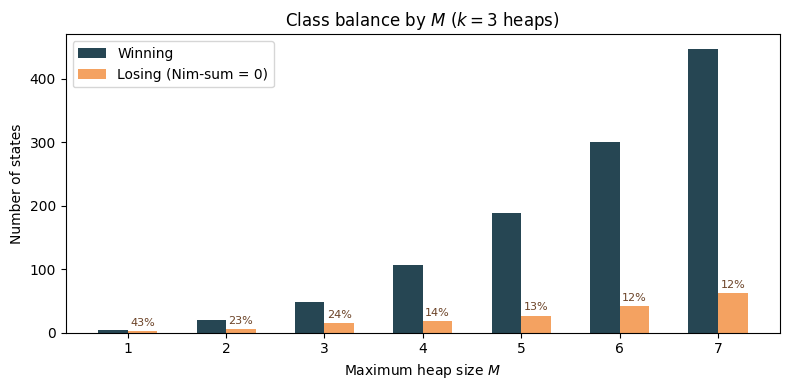

In [5]:
print(f"Total non-terminal states: {len(dataset)}")
print(f"  Winning: {dataset.is_winning.sum()}  Losing: {(1 - dataset.is_winning).sum()}")
print(f"  Move classes: {dataset.n_classes_move}")

maj_acc = majority_baseline_accuracy(dataset.is_winning)
print(f"\nMajority-class (always predict 'winning') baseline accuracy: {maj_acc:.1%}")

balance = class_balance_table(M_values=range(1, 8), k=3)
print("\nClass balance by M (k = 3 heaps):")
display(balance)

fig, ax = plt.subplots(figsize=(8, 4))
x = balance["M"]
ax.bar(x - 0.15, balance["winning"], width=0.3, label="Winning", color="#264653")
ax.bar(x + 0.15, balance["losing"], width=0.3, label="Losing (Nim-sum = 0)", color="#f4a261")
for i, row in balance.iterrows():
    ax.text(row["M"] + 0.15, row["losing"] + 5, f"{row['pct_losing']:.0f}%",
            ha="center", va="bottom", fontsize=8, color="#6b4226")
ax.set_xlabel("Maximum heap size $M$")
ax.set_ylabel("Number of states")
ax.set_title("Class balance by $M$ ($k = 3$ heaps)")
ax.legend()
ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

The heatmaps below show the win/loss pattern in the $(h_1, h_2)$ plane for each $h_3$ from 0 to 7. Losing positions (Nim-sum $= 0$, orange) satisfy $h_1 \oplus h_2 \oplus h_3 = 0$, i.e. $h_1 \oplus h_2 = h_3$. The boundary shape depends on $h_3$: at $h_3 = 0$ it is the **main diagonal** ($h_1 = h_2$); at $h_3 = 7$ the **anti-diagonal** ($h_2 = 7 - h_1$); for other values (e.g. $h_3 = 3$) the losing set is **scattered**. The XOR decision boundary is non-smooth and varies with $h_3$, which is what makes this problem hard for classical models on raw features.

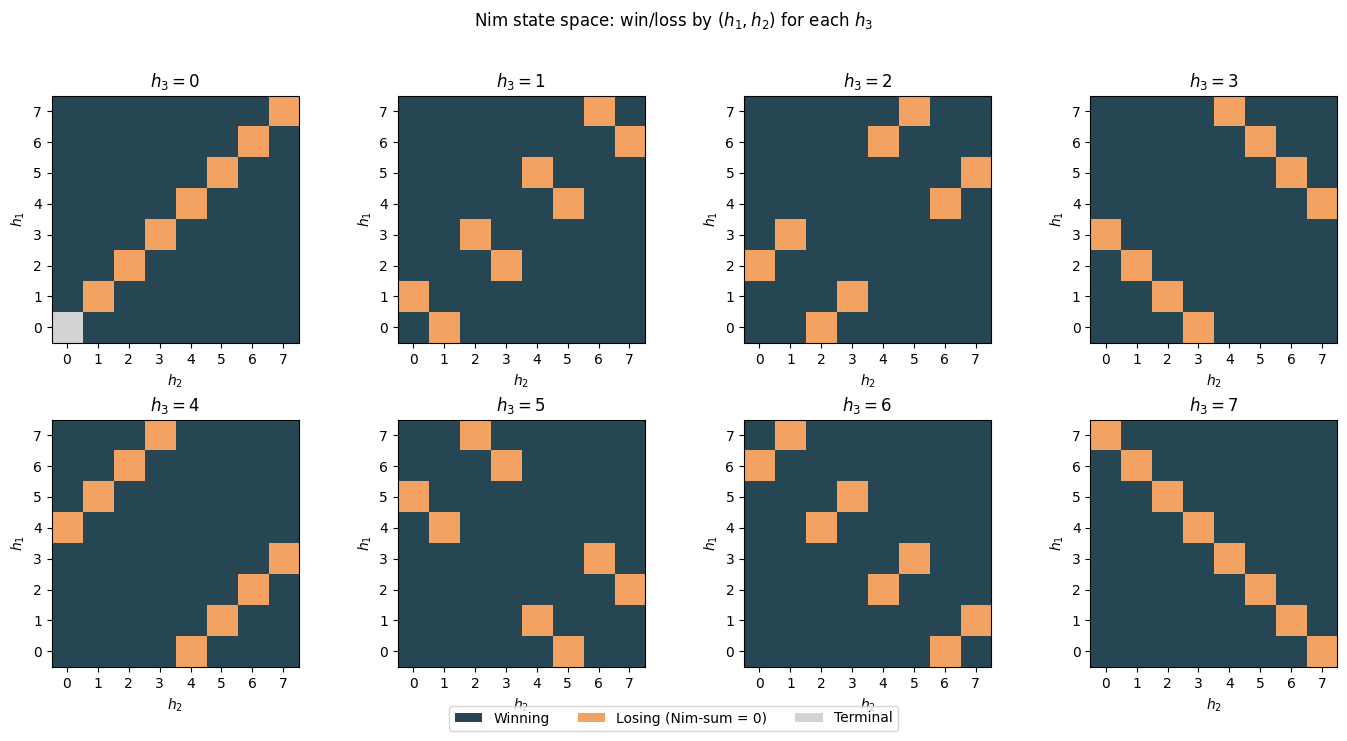

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
cmap = plt.cm.colors.ListedColormap(["lightgrey", "#f4a261", "#264653"])
for ax, h3 in zip(axes.flat, range(8)):
    grid = np.zeros((8, 8), dtype=int)
    for h1 in range(8):
        for h2 in range(8):
            if (h1, h2, h3) == (0, 0, 0) and h3 == 0:
                grid[h1, h2] = -1
            else:
                grid[h1, h2] = 1 if (h1 ^ h2 ^ h3) != 0 else 0
    ax.imshow(grid, origin="lower", cmap=cmap, vmin=-1, vmax=1)
    ax.set_xlabel("$h_2$")
    ax.set_ylabel("$h_1$")
    ax.set_title(f"$h_3 = {h3}$")
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#264653", label="Winning"),
                   Patch(facecolor="#f4a261", label="Losing (Nim-sum = 0)"),
                   Patch(facecolor="lightgrey", label="Terminal")]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Nim state space: win/loss by $(h_1, h_2)$ for each $h_3$", y=1.02)
plt.tight_layout()
fig.savefig("../presentation/figures/nim_state_space.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.5 Train/test split and training-size subsets

We use `prepare_experiment_data(k=3, M=7, M_train=5, subset_sizes=(50, 100), random_state=42)` to obtain the dataset, OOD split (`split`), and training-size subsets (50, 100, full). **Train set:** 215 states (heaps $\leq 5$). **Test set:** 296 states (at least one heap $> 5$, heaps $\leq 7$). Stratification is on the binary win/loss label so every partition preserves the ~88 / 12 class ratio. This design tests whether models learn the Nim-sum rule rather than memorising the training distribution.

**Training-size subsets:** stratified sub-samples at sizes 50, 100, and full (215). Each pipeline is trained on every subset with 10+ seeds and evaluated on the test set. All splits use `random_state=42`. No file I/O; the canonical source is code and `random_state`.

In [7]:
print("Train/test split sizes (stratified by win/loss):")
print(f"  Train (M≤5): {len(split.y_train)}   Test (M>5): {len(split.y_test)}")

Train/test split sizes (stratified by win/loss):
  Train (M≤5): 215   Test (M>5): 296


In [8]:
print("Training-size subsets for sample-efficiency sweep:")
for key in [50, 100, "full"]:
    s = subsets[key]
    print(f"  {str(key):>4s}: {s.size} samples")

Training-size subsets for sample-efficiency sweep:
    50: 50 samples
   100: 100 samples
  full: 215 samples


### 2.6 Feature normalisation

Classical features are the raw heap sizes normalised by a fixed $M_{\max} = 7$: $x_i = h_i / M_{\max} \in [0, 1]$.  This global constant ensures the feature range is consistent between train and test (training on $M \leq 5$ and testing on $M \leq 7$ use the same denominator).

In [9]:
X_norm = normalise_states(split.X_train, M_max=7)
print(f"Normalised training features: shape {X_norm.shape}, "
      f"range [{X_norm.min():.3f}, {X_norm.max():.3f}]")
print(f"Example: heaps {tuple(int(x) for x in split.X_train[0])} "
      f"→ features {tuple(round(float(x), 3) for x in X_norm[0])}")

Normalised training features: shape (215, 3), range [0.000, 0.714]
Example: heaps (0, 0, 1) → features (0.0, 0.0, 0.143)


### 2.7 Heap permutation symmetry ($S_3$)

Nim with $k = 3$ heaps has **$S_3$ permutation symmetry**: the states $(3, 5, 2)$, $(5, 2, 3)$, $(2, 3, 5)$, and all other permutations are **strategically identical** — the Nim-sum $h_1 \oplus h_2 \oplus h_3$ is invariant under heap reordering, so win/loss status and optimal strategy are unchanged. Any optimal move on one permutation maps to an optimal move on the corresponding heap in another permutation.

This symmetry is directly relevant to the **sample efficiency hypothesis**: if a model must independently learn that $(3, 5, 2)$ and $(5, 2, 3)$ are equivalent, it needs more data than one that exploits this equivalence structurally. We implement three approaches:

1. **Data augmentation** — for each training example $(h_1, h_2, h_3)$, add all distinct permutations (up to $6\times$ expansion). Straightforward; applies equally to classical and QML pipelines.
2. **Canonical ordering** — sort heaps ascending ($h_1 \leq h_2 \leq h_3$) before encoding. This collapses equivalent states into a single representative, reducing the effective state space.

In [10]:
# --- Example: S_3 symmetry of a single state ---
example = np.array([3, 5, 2])
perms = all_heap_permutations(example)
print(f"State {tuple(int(x) for x in example)} has {len(perms)} unique permutations:")
for p in perms:
    print(f"  {p}  Nim-sum = {nim_sum(p)}")

# --- Canonical ordering collapses 511 states → fewer equivalence classes ---
n_canonical = count_canonical_states(k=3, M=7)
print(f"\nCanonical states (k=3, M=7): {n_canonical} "
      f"(collapsed from {len(dataset)} raw states, "
      f"reduction factor {len(dataset)/n_canonical:.1f}×)")

# Show canonical counts across M values
print("\nCanonical state counts by M:")
for M_val in [3, 4, 5, 6, 7]:
    raw = len(enumerate_states(3, M_val))
    canon = count_canonical_states(3, M_val)
    print(f"  M={M_val}: {raw:>4} raw → {canon:>4} canonical "
          f"(reduction {raw/canon:.1f}×)")

State (3, 5, 2) has 6 unique permutations:
  (2, 3, 5)  Nim-sum = 4
  (2, 5, 3)  Nim-sum = 4
  (3, 2, 5)  Nim-sum = 4
  (3, 5, 2)  Nim-sum = 4
  (5, 2, 3)  Nim-sum = 4
  (5, 3, 2)  Nim-sum = 4

Canonical states (k=3, M=7): 119 (collapsed from 511 raw states, reduction factor 4.3×)

Canonical state counts by M:
  M=3:   63 raw →   19 canonical (reduction 3.3×)
  M=4:  124 raw →   34 canonical (reduction 3.6×)
  M=5:  215 raw →   55 canonical (reduction 3.9×)
  M=6:  342 raw →   83 canonical (reduction 4.1×)
  M=7:  511 raw →  119 canonical (reduction 4.3×)


In [11]:
# --- Data augmentation: expansion at each training size ---
print("Augmentation expansion by training-size subset:\n")
print(f"{'Subset':>8}  {'Original':>8}  {'Augmented':>9}  {'No-dedup':>8}  {'Factor':>7}")
print("-" * 52)

for key in [50, 100, "full"]:
    sub = subsets[key]
    X_aug, y_aug = augment_s3(sub.X, sub.y, deduplicate=True)
    X_aug_nd, _ = augment_s3(sub.X, sub.y, deduplicate=False)
    label = str(key) if isinstance(key, int) else f"full ({sub.size})"
    print(f"{label:>8}  {sub.size:>8}  {len(X_aug):>9}  {X_aug_nd.shape[0]:>8}  "
          f"{len(X_aug)/sub.size:>6.2f}×")

# --- Canonical ordering of the training set ---
X_canon, sort_perms = canonical_order(split.X_train)
n_unique_canon = len(np.unique(X_canon, axis=0))
print(f"\nTraining set (M≤5): {len(split.X_train)} rows → "
      f"{n_unique_canon} unique canonical forms")

Augmentation expansion by training-size subset:

  Subset  Original  Augmented  No-dedup   Factor
----------------------------------------------------
      50        50        153       300    3.06×
     100       100        201       600    2.01×
full (215)       215        215      1290    1.00×

Training set (M≤5): 215 rows → 55 unique canonical forms


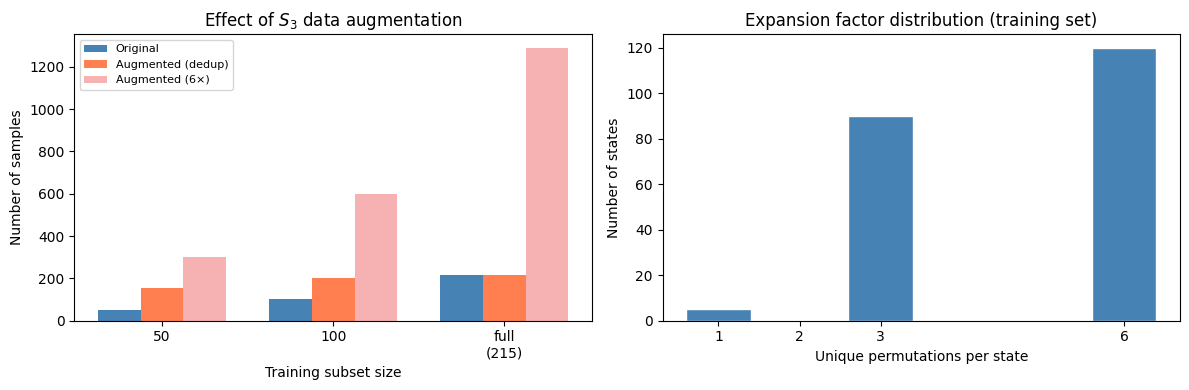

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: augmented size vs original size for each subset
subset_keys = [50, 100, "full"]
orig_sizes, aug_sizes, aug_nd_sizes = [], [], []
for key in subset_keys:
    sub = subsets[key]
    X_a, _ = augment_s3(sub.X, sub.y, deduplicate=True)
    X_and, _ = augment_s3(sub.X, sub.y, deduplicate=False)
    orig_sizes.append(sub.size)
    aug_sizes.append(len(X_a))
    aug_nd_sizes.append(len(X_and))

x_pos = np.arange(len(subset_keys))
w = 0.25
axes[0].bar(x_pos - w, orig_sizes, w, label="Original", color="steelblue")
axes[0].bar(x_pos, aug_sizes, w, label="Augmented (dedup)", color="coral")
axes[0].bar(x_pos + w, aug_nd_sizes, w, label="Augmented (6×)", color="lightcoral", alpha=0.6)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(k) if isinstance(k, int) else f"full\n({subsets[k].size})" for k in subset_keys])
axes[0].set_xlabel("Training subset size")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Effect of $S_3$ data augmentation")
axes[0].legend(fontsize=8)

# Right: per-state expansion factor distribution (full training set)
stats = augmentation_stats(split.X_train)
counts = stats["n_unique_perms"].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Unique permutations per state")
axes[1].set_ylabel("Number of states")
axes[1].set_title("Expansion factor distribution (training set)")
axes[1].set_xticks([1, 2, 3, 6])

plt.tight_layout()
plt.show()

**Observations:**

- The 511 non-terminal states collapse to just **119 canonical equivalence classes** under $S_3$ — a $4.3\times$ reduction. States with all-distinct heaps (expansion factor 6) dominate; states with two or three equal heaps contribute fewer unique permutations.
- **Data augmentation benefit scales inversely with training set size.** At 50 samples, augmentation yields a substantial expansion (most of the 6 unique permutations are genuinely new). At full training size (215), deduplication collapses much of the expansion because the training set already covers most permutations.
- **Canonical ordering** reduces the input space by a fixed $4.3\times$ regardless of training size, but discards heap identity (which heap to take from). For **win/loss classification**, this is a clean simplification. For **move prediction**, the sort permutation must be stored to remap predicted moves back to the original heap ordering (`remap_move_to_original`).

Both approaches will be used as controlled variables in the sample-efficiency experiment, comparing raw vs augmented vs canonical at each training size for both classical and QML pipelines.

## 3. Classical ML Baseline

We train three classifiers — **SVM (RBF kernel)**, **Random Forest**, and **Logistic Regression** — on the win/loss classification task. All models use `class_weight='balanced'` to address the ~88/12 class imbalance (§2.4).

**Feature variants:**
- **Raw:** normalised heap sizes $(h_i / M_{\max})$ — 3 features.
- **Parity:** raw features augmented with heap parities ($h_i \bmod 2$), pairwise XOR values ($h_i \oplus h_j$ normalised), and column-wise bit parities (individual bits of the Nim-sum) — 12 features total.

**Symmetry variants:** Each configuration is tested both **without** and **with** $S_3$ data augmentation (§2.7).

**Sample efficiency:** Each configuration is trained on subsets of size 50, 100, and full (215) with **10 seeds** per configuration. Each seed produces a different stratified subsample, so variance reflects both data sampling and (for Random Forest) model randomness.

**Evaluation:** Balanced accuracy (primary), MCC, F1, and win rate vs random (500 games per configuration).

### 3.1 Feature engineering preview

Before running the full sweep, we inspect the two feature sets on a single example.

In [13]:
example_states = np.array([[3, 5, 2], [4, 4, 0], [7, 7, 7]])
raw = prepare_features(example_states, "raw", M=7)
par = prepare_features(example_states, "parity", M=7)

feature_names_raw = ["h0/M", "h1/M", "h2/M"]
feature_names_par = (
    feature_names_raw
    + ["h0%2", "h1%2", "h2%2"]
    + ["h0^h1/M", "h0^h2/M", "h1^h2/M"]
    + ["bit0_par", "bit1_par", "bit2_par"]
)

print("Raw features (3):")
_idx = [str(tuple(int(x) for x in s)) for s in example_states]
print(pd.DataFrame(raw, columns=feature_names_raw, index=_idx).round(3))
print(f"\nParity features ({par.shape[1]}):")
print(pd.DataFrame(par, columns=feature_names_par, index=_idx).round(3))

Raw features (3):
            h0/M   h1/M   h2/M
(3, 5, 2)  0.429  0.714  0.286
(4, 4, 0)  0.571  0.571  0.000
(7, 7, 7)  1.000  1.000  1.000

Parity features (12):
            h0/M   h1/M   h2/M  h0%2  h1%2  h2%2  h0^h1/M  h0^h2/M  h1^h2/M  \
(3, 5, 2)  0.429  0.714  0.286   1.0   1.0   0.0    0.857    0.143    1.000   
(4, 4, 0)  0.571  0.571  0.000   0.0   0.0   0.0    0.000    0.571    0.571   
(7, 7, 7)  1.000  1.000  1.000   1.0   1.0   1.0    0.000    0.000    0.000   

           bit0_par  bit1_par  bit2_par  
(3, 5, 2)       0.0       0.0       1.0  
(4, 4, 0)       0.0       0.0       0.0  
(7, 7, 7)       1.0       1.0       1.0  


### 3.1.0 Parity and bit parity

Before visualising the feature spaces, we define what the parity-style features represent and why they matter for Nim.

- **Heap parity:** $h_i \bmod 2$ — odd/even per heap (3 features).
- **Pairwise XOR:** $h_i \oplus h_j$ normalised by $M$ — XOR of each pair of heaps (3 features).
- **Column-wise bit parity:** for each bit position $b$, the XOR of that bit across the three heaps. Formally, bit $b$ is $\bigoplus_i \lfloor h_i / 2^b \rfloor \bmod 2$, i.e. the $b$-th bit of the Nim-sum (3 features for $M = 7$).

**Why it matters:** A position is **losing** if and only if Nim-sum $= 0$, which is equivalent to all bit parities being zero. So the **bit parities are exactly the bits of the Nim-sum**; a linear classifier on those bits can achieve perfect win/loss classification. The next plot shows this geometrically: in 2D PCA, raw features do not separate the classes, whereas parity and bit-parity features do. A more detailed ablation of parity-style feature sets is in §3.6.

### 3.1.1 Feature space visualization

We visualise the OOD train set in raw, parity, and bit-parity feature spaces via PCA (2 components). Points are coloured by win/loss. This shows why parity features separate the classes and raw features do not.

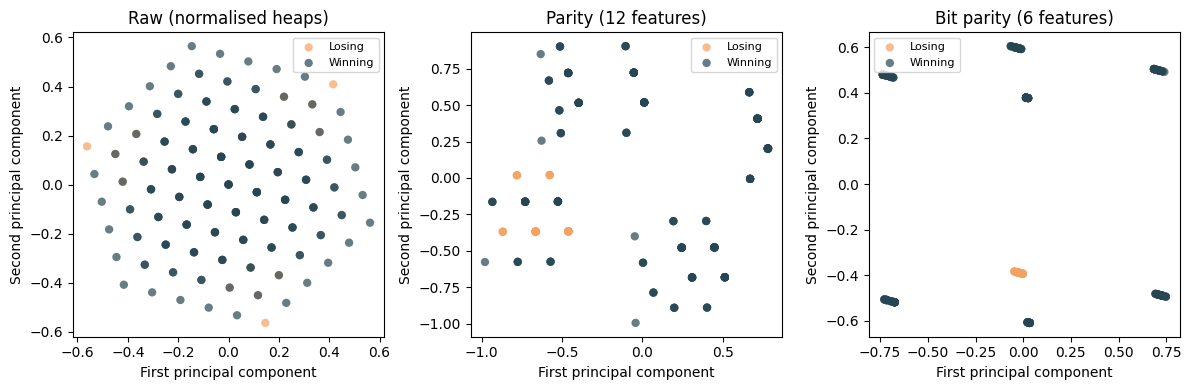

In [14]:
from sklearn.decomposition import PCA

M = 7
X_train_raw = prepare_features(split.X_train, "raw", M=M)
X_train_parity = prepare_features(split.X_train, "parity", M=M)
X_train_bit = prepare_features(split.X_train, "bit_parity", M=M)
y = split.y_train

pca_raw = PCA(n_components=2).fit(X_train_raw)
pca_parity = PCA(n_components=2).fit(X_train_parity)
pca_bit = PCA(n_components=2).fit(X_train_bit)

Z_raw = pca_raw.transform(X_train_raw)
Z_parity = pca_parity.transform(X_train_parity)
Z_bit = pca_bit.transform(X_train_bit)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#f4a261", "#264653"]  # losing, winning
labels = ["Losing", "Winning"]

for ax, Z, title in [
    (axes[0], Z_raw, "Raw (normalised heaps)"),
    (axes[1], Z_parity, "Parity (12 features)"),
    (axes[2], Z_bit, "Bit parity (6 features)"),
]:
    for cls, color, label in [(0, colors[0], labels[0]), (1, colors[1], labels[1])]:
        mask = y == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=label, alpha=0.7, edgecolors="none")
    ax.set_xlabel("First principal component")
    ax.set_ylabel("Second principal component")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
axes[0].set_ylabel("Second principal component")
plt.tight_layout()
fig.savefig("../presentation/figures/feature_space_pca.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure:** 2D PCA of raw vs parity feature spaces (OOD train set), coloured by win/loss. Parity and bit-parity features separate the classes; raw (normalised heaps) do not.

### 3.2 Sample-efficiency sweep

We train on $M \leq 5$ (subsets 50, 100, full = 215) and test on $M > 5$ (296 states). 3 models $\times$ 2 feature sets $\times$ 2 symmetry variants $\times$ 3 training sizes $\times$ 10 seeds = **360 configurations** with win-rate evaluation (200 games each).

In [15]:
sweep = run_classical_sweep(
    split.X_train, split.y_train,
    split.X_test, split.y_test,
    model_names=["SVM (RBF)", "Random Forest", "Logistic Regression"],
    feature_sets=["raw", "parity"],
    symmetry_variants=["none", "augmented"],
    train_sizes=[50, 100, "full"],
    seeds=list(range(10)),
    M=7,
    compute_win_rate=True,
    n_games_win_rate=200,
    mlflow_experiment="classical-baselines",
    verbose=True,
)

  Loaded 360 runs from MLflow cache.
  [20/360] runs complete
  [40/360] runs complete
  [60/360] runs complete
  [80/360] runs complete
  [100/360] runs complete
  [120/360] runs complete
  [140/360] runs complete
  [160/360] runs complete
  [180/360] runs complete
  [200/360] runs complete
  [220/360] runs complete
  [240/360] runs complete
  [260/360] runs complete
  [280/360] runs complete
  [300/360] runs complete
  [320/360] runs complete
  [340/360] runs complete
  [360/360] runs complete
  Sweep complete: 360 runs.


### 3.3 Summary metrics

Mean $\pm$ std over 10 seeds for balanced accuracy, MCC, and win rate at each training size.

In [16]:
sweep_df = sweep.to_dataframe()
sweep_summary = sweep.summary()

display_cols = [
    "model", "feature_set", "symmetry", "train_size",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
    "win_rate_mean", "win_rate_std",
]
summary_display = sweep_summary[display_cols].copy()
for col in ["balanced_accuracy_mean", "balanced_accuracy_std", "mcc_mean", "mcc_std",
             "win_rate_mean", "win_rate_std"]:
    summary_display[col] = summary_display[col].round(3)

pd.set_option("display.max_rows", None)
summary_display

,model,feature_set,symmetry,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,win_rate_mean,win_rate_std
0,Logistic Regression,parity,augmented,50,0.998,0.005,0.988,0.038,0.987,0.041
1,Logistic Regression,parity,augmented,100,1.000,0.000,1.000,0.000,1.000,0.000
2,Logistic Regression,parity,augmented,215,1.000,0.000,1.000,0.000,1.000,0.000
3,Logistic Regression,parity,none,50,0.939,0.057,0.864,0.121,0.890,0.154
4,Logistic Regression,parity,none,100,1.000,0.000,1.000,0.000,1.000,0.000
5,Logistic Regression,parity,none,215,1.000,0.000,1.000,0.000,1.000,0.000
6,Logistic Regression,raw,augmented,50,0.499,0.022,-0.008,0.074,0.508,0.032
7,Logistic Regression,raw,augmented,100,0.477,0.000,-0.076,0.000,0.507,0.012
8,Logistic Regression,raw,augmented,215,0.477,0.000,-0.076,0.000,0.507,0.012
9,Logistic Regression,raw,none,50,0.485,0.033,-0.034,0.060,0.500,0.038


### 3.4 Sample-efficiency curves

Balanced accuracy and win rate vs training set size.

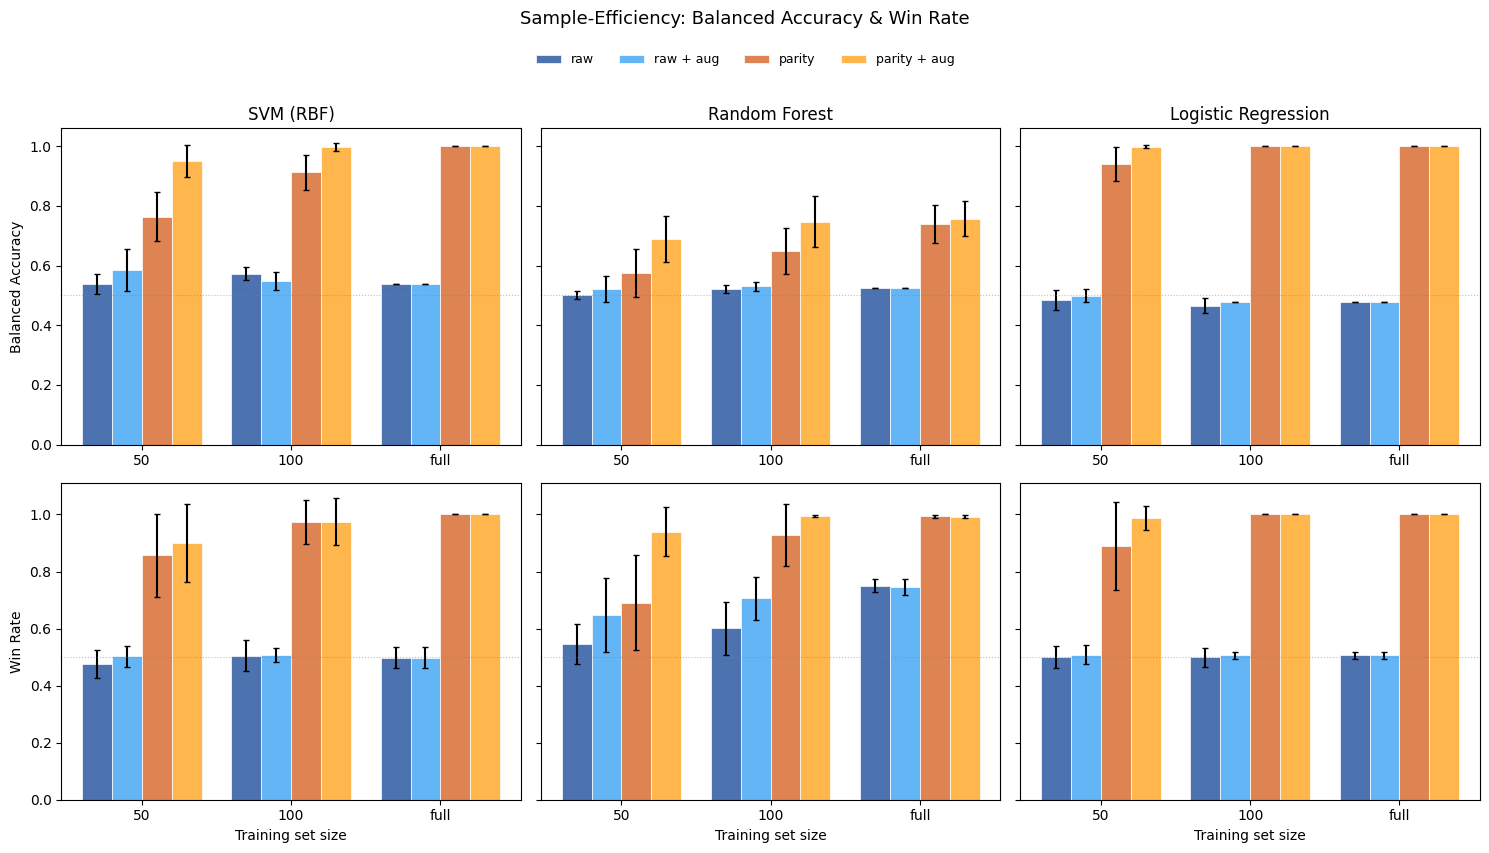

In [17]:
models = ["SVM (RBF)", "Random Forest", "Logistic Regression"]
configs = [
    ("raw", "none"),
    ("raw", "augmented"),
    ("parity", "none"),
    ("parity", "augmented"),
]
config_labels = ["raw", "raw + aug", "parity", "parity + aug"]
config_colors = ["#4c72b0", "#64b5f6", "#dd8452", "#ffb74d"]
metrics = [
    ("balanced_accuracy", "Balanced Accuracy"),
    ("win_rate", "Win Rate"),
]

train_sizes = sorted(sweep_df["train_size"].unique())
n_sizes = len(train_sizes)
n_bars = len(configs)
bar_width = 0.8 / n_bars

fig, axes = plt.subplots(len(metrics), len(models), figsize=(15, 8),
                         sharey="row")

for row, (metric, metric_label) in enumerate(metrics):
    for col, model in enumerate(models):
        ax = axes[row, col]
        for b, ((fs, sym), label, color) in enumerate(
            zip(configs, config_labels, config_colors)
        ):
            mask = (
                (sweep_df["model"] == model)
                & (sweep_df["feature_set"] == fs)
                & (sweep_df["symmetry"] == sym)
            )
            grouped = sweep_df[mask].groupby("train_size")[metric].agg(["mean", "std"])
            grouped = grouped.reindex(train_sizes)
            x = np.arange(n_sizes) + b * bar_width
            ax.bar(
                x, grouped["mean"], bar_width,
                yerr=grouped["std"], label=label if (row == 0 and col == 0) else None,
                color=color, capsize=2, edgecolor="white", linewidth=0.5,
            )
        ax.set_xticks(np.arange(n_sizes) + bar_width * (n_bars - 1) / 2)
        ax.set_xticklabels([str(s) if s != 215 else "full" for s in train_sizes])
        ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5, linewidth=0.8)
        if row == len(metrics) - 1:
            ax.set_xlabel("Training set size")
        if col == 0:
            ax.set_ylabel(metric_label)
        if row == 0:
            ax.set_title(model)

fig.legend(
    *axes[0, 0].get_legend_handles_labels(),
    loc="upper center", ncol=n_bars, frameon=False,
    bbox_to_anchor=(0.5, 1.02), fontsize=9,
)
fig.suptitle("Sample-Efficiency: Balanced Accuracy & Win Rate", y=1.06, fontsize=13)
plt.tight_layout()
fig.savefig("../presentation/figures/sample_efficiency_split.png", dpi=200, bbox_inches="tight")
plt.show()

### 3.6 Feature ablation

To avoid strawman comparisons with QML and understand *which* engineered features drive the leap from ~54% (OOD raw) to ~100% (parity) balanced accuracy, we run an ablation study on SVM (RBF). Each ablation subset adds one feature group to the normalised heap sizes:

| Feature set | Dim | Added features |
|---|---|---|
| `raw` | 3 | Normalised heap sizes only |
| `heap_parity` | 6 | + per-heap parities ($h_i \bmod 2$) |
| `pairwise_xor` | 6 | + pairwise XOR ($h_i \oplus h_j / M$) |
| `bit_parity` | 6 | + column-wise bit parities (individual Nim-sum bits) |
| `parity` | 12 | All of the above |

The **column-wise bit parities** encode the individual bits of the Nim-sum (bit $b$ is $\bigoplus_i \lfloor h_i / 2^b \rfloor \bmod 2$). A linear model can combine them to perfectly classify win/loss, since $\text{Nim-sum} = 0 \iff$ all bit parities are zero. This makes `bit_parity` the most structurally relevant ablation subset for the Nim problem.

The ablation below compares **parity-style feature sets only** (heap_parity, pairwise_xor, bit_parity, parity); the raw-feature baseline is reported in the main sweep and sample-efficiency plot (§3.5).

**Note on the plot:** The "All parity features (12)" bars can be *shorter* than the "+ column bit parities (6)" bars — this is expected. At small training sizes the full parity set underperforms bit parities alone because the extra dimensions (heap parities, pairwise XOR) add noise when data is scarce; bit parities already suffice for perfect Nim-sum classification. At full training size both reach 1.0.

In [18]:
from qml_project.baselines import ABLATION_FEATURE_SETS_NO_RAW, FEATURE_SET_DESCRIPTIONS

ablation_sweep = run_classical_sweep(
    split.X_train, split.y_train,
    split.X_test, split.y_test,
    model_names=["SVM (RBF)"],
    feature_sets=ABLATION_FEATURE_SETS_NO_RAW,
    symmetry_variants=["none"],
    train_sizes=[50, 100, "full"],
    seeds=list(range(10)),
    M=7,
    compute_win_rate=False,
    mlflow_experiment="classical-ablation",
    verbose=True,
)

abl_summary = ablation_sweep.summary(
    group_cols=("feature_set", "train_size"),
)
abl_display = abl_summary[[
    "feature_set", "train_size",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
]].copy()
for col in abl_display.columns[2:]:
    abl_display[col] = abl_display[col].round(3)

abl_display["description"] = abl_display["feature_set"].map(FEATURE_SET_DESCRIPTIONS)
print("Feature ablation — SVM (RBF), no symmetry augmentation:")
display(abl_display)

  Loaded 120 runs from MLflow cache.
  [20/120] runs complete
  [40/120] runs complete
  [60/120] runs complete
  [80/120] runs complete
  [100/120] runs complete
  [120/120] runs complete
  Sweep complete: 120 runs.
Feature ablation — SVM (RBF), no symmetry augmentation:


,feature_set,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,description
0,bit_parity,50,0.944,0.045,0.935,0.053,+ column bit parities (6)
1,bit_parity,100,0.996,0.007,0.995,0.008,+ column bit parities (6)
2,bit_parity,215,1.000,0.000,1.000,0.000,+ column bit parities (6)
3,heap_parity,50,0.562,0.038,0.108,0.058,+ heap parities (6)
4,heap_parity,100,0.631,0.040,0.196,0.047,+ heap parities (6)
5,heap_parity,215,0.785,0.000,0.372,0.000,+ heap parities (6)
6,pairwise_xor,50,0.541,0.045,0.079,0.070,+ pairwise XOR (6)
7,pairwise_xor,100,0.537,0.027,0.070,0.047,+ pairwise XOR (6)
8,pairwise_xor,215,0.573,0.000,0.146,0.000,+ pairwise XOR (6)
9,parity,50,0.764,0.082,0.698,0.114,All parity features (12)


In [19]:
# Centralised plot labels for training sizes (used by ablation and sample-efficiency bar charts)
size_labels = {50: "50", 100: "100", 215: "full"}
train_sizes = sorted(size_labels.keys())

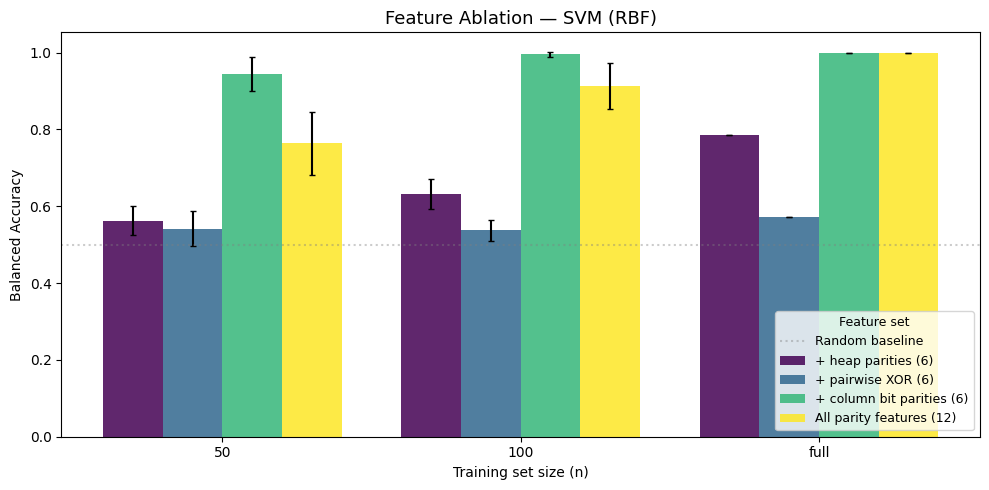

In [20]:
abl_df = ablation_sweep.to_dataframe()

n_fs = len(ABLATION_FEATURE_SETS_NO_RAW)
n_sizes = len(train_sizes)
bar_width = 0.2
size_offsets = np.arange(n_sizes)

fig, ax = plt.subplots(figsize=(10, 5))

for j, fs in enumerate(ABLATION_FEATURE_SETS_NO_RAW):
    sub = abl_df[abl_df["feature_set"] == fs]
    means = sub.groupby("train_size")["balanced_accuracy"].mean()
    stds = sub.groupby("train_size")["balanced_accuracy"].std()
    vals = [means.get(tsz, np.nan) for tsz in train_sizes]
    errs = [stds.get(tsz, 0) for tsz in train_sizes]
    x = size_offsets + (j - (n_fs - 1) / 2) * bar_width
    ax.bar(x, vals, bar_width, yerr=errs, capsize=2,
           label=FEATURE_SET_DESCRIPTIONS[fs], alpha=0.85,
           color=plt.cm.viridis(j / (n_fs - 1)))

ax.set_xticks(size_offsets)
ax.set_xticklabels([size_labels[tsz] for tsz in train_sizes])
ax.set_xlabel("Training set size (n)")
ax.set_ylabel("Balanced Accuracy")
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.4, label="Random baseline")
ax.legend(title="Feature set", fontsize=9, title_fontsize=9, loc="lower right")
ax.set_title("Feature Ablation — SVM (RBF)", fontsize=13)
plt.tight_layout()
fig.savefig("../presentation/figures/feature_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.7 Strengthened baselines: key findings

Results below are from the same sample-efficiency design (train M≤5, test M>5).

**Feature ablation:**
- The **column-wise bit parities** (`bit_parity`) are by far the most informative feature group, since they directly encode the individual bits of the Nim-sum. SVM (RBF) with bit parities alone achieves 0.995 balanced accuracy at just 50 training samples and perfect 1.000 at $\geq 100$.
- **Heap parities** ($h_i \bmod 2$) and **pairwise XOR** each improve over raw features but fall well short of the bit parities (~0.77 and ~0.79 at full training size, respectively). This confirms that Nim-sum classification requires access to the full bitwise parity structure, not just single-heap or pairwise information.
- The full `parity` set (all 12 features) does **not** improve over `bit_parity` alone — at 50 samples the full set (0.870) actually *underperforms* bit parities (0.995), likely because the extra feature dimensions add noise when data is scarce. At full (215) samples the two converge to perfect accuracy.

**Implication for QML:** The feature ablation shows that the *right features* make the problem trivially solvable. The question for QML is whether the quantum feature map can implicitly discover equivalent structure (particularly the bitwise XOR) without explicit feature engineering — and whether it can do so more sample-efficiently than classical models on raw features.

### 3.8 Why Nim is a relevant testbed for QML

The classical results above reveal a sharp structural divide in the Nim classification problem that makes it well-suited for investigating quantum machine learning.

**The Nim-sum boundary is an XOR function.** A position $(h_1, h_2, h_3)$ is losing if and only if $h_1 \oplus h_2 \oplus h_3 = 0$, where $\oplus$ denotes bitwise XOR. This decision boundary is a *parity function* over the binary representations of the heap sizes. Parity functions are a classical hard case for many learning algorithms: they cannot be represented by any bounded-degree polynomial over the raw inputs, and kernel methods with smooth kernels (such as RBF) must approximate a highly non-smooth boundary. Our results confirm this. SVM (RBF) on raw heap sizes plateaus at ~0.54 balanced accuracy on the OOD test set (M>5) even with the full training set (215 samples), and Logistic Regression does no better than chance (~0.47). The decision boundary is invisible to models that rely on smooth interpolation of continuous features.

**Parity features make the problem trivial.** When we supply the column-wise bit parities (the individual bits of the Nim-sum) as engineered features, the problem becomes linearly separable. SVM and Logistic Regression both achieve perfect classification with as few as 50 training samples. The feature ablation (§3.6) isolates this effect precisely: bit parities alone saturate performance, while heap-level parities and pairwise XOR each capture only partial structure. This gap between "raw features, hard" and "right features, trivial" is the crux of the QML question.

**The sample efficiency hypothesis.** Quantum feature maps based on rotation gates and entangling operations can, by construction, encode phase relationships that correspond to parity functions. Angle encoding maps each heap size to a qubit rotation $R_Y(h_i \pi / M)$, placing the input into a Hilbert space where the inner product between states depends on trigonometric functions of the differences. Binary encoding goes further: representing each heap in a 3-bit binary string on 9 qubits and entangling corresponding bit positions across heaps mirrors the bitwise XOR of the Nim-sum directly. If the quantum feature map implicitly captures the XOR structure that classical models on raw features cannot access, the VQC should learn faster from fewer examples.

**What QML needs to beat.** The classical baselines establish two reference points (from the sample-efficiency experiment: train M≤5, test M>5):

| Baseline | Raw features | Parity features |
|---|---|---|
| SVM (RBF), full training set (215), OOD test | ~0.54 bal. acc., ~0.48 win rate | 1.000 bal. acc., 1.000 win rate |
| Best classical at 50 samples | ~0.59 bal. acc. (SVM-RBF) | ~0.99 bal. acc. (SVM-RBF with bit parities) |

**Generalisation.** Our design (train on $M \leq 5$, test on $M > 5$) directly tests whether models learn the Nim-sum rule rather than memorising the training distribution. SVM and Logistic Regression with parity features generalise perfectly (1.000 OOD); Random Forest with parity reaches 0.74 OOD at full training, so it memorises more than it generalises. Classical models on raw features collapse to near-chance on the test set (~0.54 balanced accuracy). If the quantum feature map genuinely encodes XOR structure, QML on raw features should generalise better than its classical counterpart on raw features. That would be evidence that the model has learned the *rule* rather than memorised the training distribution.

**Symmetry as inductive bias.** The $S_3$ heap permutation symmetry provides a third axis for the comparison. Data augmentation helps Random Forest dramatically on raw features (0.48 $\to$ 1.00 balanced accuracy at full training size, 215), showing that the symmetry information is highly valuable. Whether canonical ordering or equivariant circuit design can deliver similar gains for QML, especially at small training sizes, is a natural question for the QML pipeline (§5).

### 3.9 Theory-kernel framing: Nim-sum/XOR and angle feature maps

For the angle map used in the 3-qubit baseline,

$$
|\psi(x)\rangle = \bigotimes_{i=1}^3 R_Y\!\left(\frac{\pi x_i}{1}\right)|0\rangle
\quad\text{with }x_i=h_i/M_{\max}\in[0,1],
$$

the induced kernel is

$$
k_{\text{angle}}(x,x') = \left|\langle\psi(x)|\psi(x')\rangle\right|^2
= \prod_{i=1}^3 \cos^2\!\left(\frac{\pi(x_i-x_i')}{2}\right).
$$

Using $\cos^2(\alpha)=\tfrac12(1+\cos(2\alpha))$ and product expansion,
$k_{\text{angle}}$ contains interaction terms that multiply trigonometric responses across heaps (including 2-way and 3-way products). These interaction terms are the key reason the kernel can model XOR-like boundaries better than purely linear models on raw features: parity information is represented through phase interactions in feature space rather than explicit hand-crafted bit-parity features.

This is not a formal quantum advantage proof. It is a representational argument: the kernel feature space naturally includes high-order cross-heap terms that are relevant to Nim-sum parity.

Below we compare the angle kernel to classical RBF and polynomial kernels using:

- **Visual structure:** kernel matrices (same data ordering)
- **Quantitative separation:** centered kernel alignment (CKA) to the binary target kernel $yy^\top$ and same-class minus different-class similarity gap
- **Aligned classical baseline:** SVM with `SVM (Angle Kernel)` vs `SVM (RBF)` on the same raw features and OOD protocol

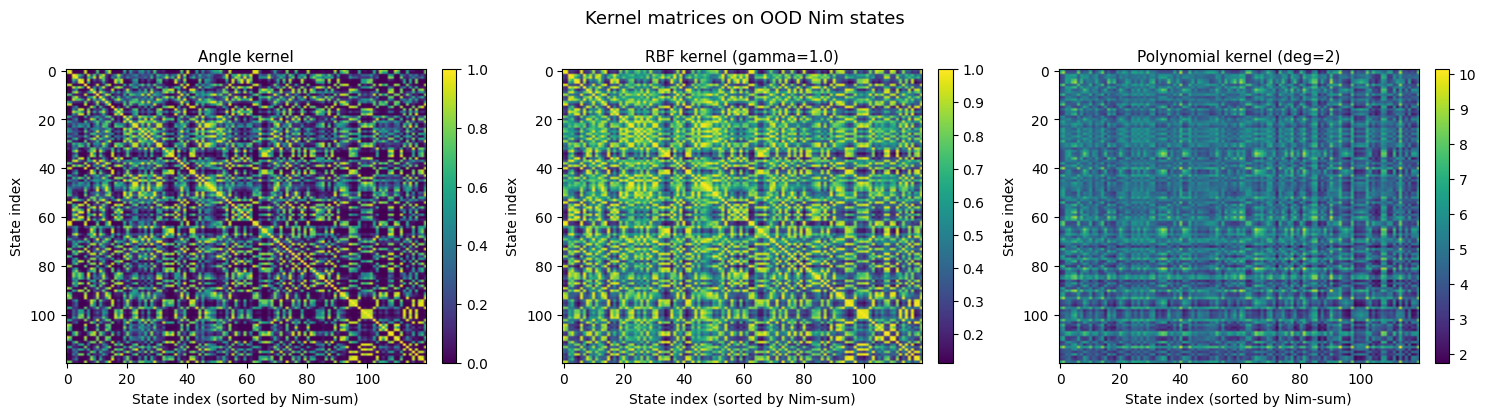

Kernel diagnostics (higher CKA and larger class-gap are better):


,kernel,cka_to_target,mean_same_class,mean_diff_class,gap_same_minus_diff,trace
0,angle,0.0070,0.3032,0.3274,-0.0242,120.000
1,rbf,0.0035,0.5708,0.5923,-0.0215,120.000
2,poly,0.0019,4.7818,4.9081,-0.1264,762.454



Kernel-aligned classical baseline (raw features, OOD):


,model,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,win_rate_mean,win_rate_std
0,SVM (Angle Kernel),50,0.5156,0.0484,0.0216,0.4875,0.0745
4,SVM (RBF),50,0.5382,0.0330,0.0612,0.4750,0.0486
1,SVM (Angle Kernel),100,0.5506,0.0274,0.0796,0.4835,0.0546
5,SVM (RBF),100,0.5717,0.0218,0.1087,0.5050,0.0542
2,SVM (Angle Kernel),200,0.5753,0.0109,0.1261,0.5090,0.0420
6,SVM (RBF),200,0.5501,0.0194,0.0773,0.5040,0.0278
3,SVM (Angle Kernel),215,0.5744,0.0000,0.1209,0.4950,0.0443
7,SVM (RBF),215,0.5385,0.0000,0.0651,0.4980,0.0379


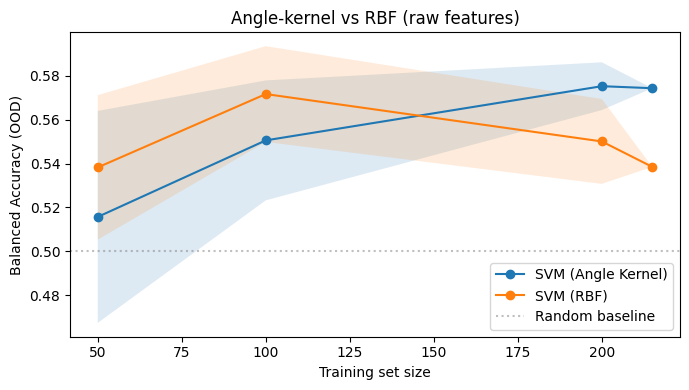

In [21]:
# Kernel-matrix comparison on a fixed OOD test subset (ordered by Nim-sum)
X_kernel_raw = split.X_test.copy()
y_kernel = split.y_test.copy()

order = np.argsort(np.array([nim_sum(tuple(s)) for s in X_kernel_raw]))
X_kernel_raw = X_kernel_raw[order]
y_kernel = y_kernel[order]

# Keep the figure readable while preserving both classes.
max_rows = 120
X_kernel_raw = X_kernel_raw[:max_rows]
y_kernel = y_kernel[:max_rows]

X_kernel = normalise_states(X_kernel_raw, M_max=7)

K_angle = angle_encoding_kernel(X_kernel, X_kernel, M=7)
K_rbf = rbf_kernel(X_kernel, X_kernel, gamma=1.0)
K_poly = polynomial_kernel(X_kernel, X_kernel, degree=2, gamma=1.0, coef0=1.0)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, K, title in [
    (axs[0], K_angle, "Angle kernel"),
    (axs[1], K_rbf, "RBF kernel (gamma=1.0)"),
    (axs[2], K_poly, "Polynomial kernel (deg=2)"),
]:
    im = ax.imshow(K, cmap="viridis", aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("State index (sorted by Nim-sum)")
    ax.set_ylabel("State index")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Kernel matrices on OOD Nim states", fontsize=13)
plt.tight_layout()
plt.show()

# Quantitative comparison: alignment to target labels and class separation.
kernel_cmp = compare_kernels_for_nim(
    X_kernel,
    y_kernel,
    M=7,
    rbf_gamma=1.0,
    poly_degree=2,
    poly_gamma=1.0,
    poly_coef0=1.0,
).sort_values("cka_to_target", ascending=False)

kernel_cmp_display = kernel_cmp.copy()
for col in ["cka_to_target", "mean_same_class", "mean_diff_class", "gap_same_minus_diff", "trace"]:
    kernel_cmp_display[col] = kernel_cmp_display[col].map(lambda v: round(float(v), 4))

print("Kernel diagnostics (higher CKA and larger class-gap are better):")
display(kernel_cmp_display)

# Aligned classical baseline: same raw inputs, two kernels only.
kernel_baseline_sweep = run_classical_sweep(
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    model_names=("SVM (RBF)", "SVM (Angle Kernel)"),
    feature_sets=("raw",),
    symmetry_variants=("none",),
    train_sizes=(50, 100, 200, "full"),
    seeds=tuple(range(10)),
    M=7,
    compute_win_rate=True,
    n_games_win_rate=200,
    mlflow_experiment="classical-kernel-aligned",
    use_cache=True,
    force_rerun=False,
    verbose=False,
)

kernel_summary = kernel_baseline_sweep.summary(group_cols=("model", "train_size", "regime"))
cols = [
    "model", "train_size", "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "win_rate_mean", "win_rate_std",
]
kernel_summary_display = kernel_summary[cols].copy().sort_values(["train_size", "model"])
for c in ["balanced_accuracy_mean", "balanced_accuracy_std", "mcc_mean", "win_rate_mean", "win_rate_std"]:
    kernel_summary_display[c] = kernel_summary_display[c].map(lambda v: round(float(v), 4))

print("\nKernel-aligned classical baseline (raw features, OOD):")
display(kernel_summary_display)

# Compact learning-curve view.
plot_df = kernel_summary.copy()
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for model_name, sub in plot_df.groupby("model"):
    sub = sub.sort_values("train_size")
    x = sub["train_size"].to_numpy()
    y = sub["balanced_accuracy_mean"].to_numpy()
    e = sub["balanced_accuracy_std"].fillna(0).to_numpy()
    ax.plot(x, y, marker="o", label=model_name)
    ax.fill_between(x, np.maximum(0, y - e), np.minimum(1, y + e), alpha=0.15)

ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5, label="Random baseline")
ax.set_xlabel("Training set size")
ax.set_ylabel("Balanced Accuracy (OOD)")
ax.set_title("Angle-kernel vs RBF (raw features)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.**

- If the angle kernel shows higher target alignment (CKA) and a larger same-vs-different class gap than RBF/polynomial on the same states, this supports the parity-sensitive feature-space argument.
- The `SVM (Angle Kernel)` baseline is deliberately *classical training + quantum-structured similarity*: any gain over RBF isolates the contribution of the feature map itself, before introducing variational optimisation.
- This section establishes the theoretical and empirical bridge needed before the full quantum-kernel SVM pipeline in §5.4.

## 4. QML Input Transformation

*Supports: Input Transformation & Data Prep (10%)*

We implement a staged encoding strategy for the heap vector:

1. **Angle encoding (default starter):** 3 qubits with $\theta_i = h_i \cdot \pi / M$.
2. **Amplitude encoding (pilot):** compact state preparation to test qubit savings vs initialisation overhead.
3. **Binary encoding:** 9 qubits (3 bits per heap) with bit-position entanglement aligned to Nim-sum XOR.
4. **IQP/parity feature map:** phase interactions that emphasise XOR-like structure.

All variants use fixed normalisation by $M_{\max}=7$ for OOD consistency, and can apply symmetry handling via canonical ordering or equivariant entanglement. Promotion to full sweeps is gated by explicit go/no-go criteria on qubits, depth, runtime, and OOD balanced accuracy.

Binary encoding is treated as **conditional scope**: we keep it only if OOD and sample-efficiency gains justify its higher depth/runtime relative to angle and amplitude pilots. If runtime or depth increases are disproportionate to the performance gain, the binary track is deferred and angle (plus amplitude pilot evidence) remains the primary path.

**References:** [18], [20].

In [22]:
from qml_project.nim import (
    ENCODING_CANDIDATES,
    BinaryScopeCriteria,
    EncodingGoNoGoCriteria,
    angle_parameters,
    amplitude_vector,
    binary_bits,
    build_encoding_circuit,
    compare_encoding_pilots,
    evaluate_binary_scope,
    pilot_metrics_from_observation,
    select_encodings_for_sweeps,
)

example_state = (3, 5, 2)

theta = angle_parameters(example_state, M=7)
amp = amplitude_vector(example_state, M=7)
bits = binary_bits(example_state)

circuits = {
    "angle": build_encoding_circuit("angle", example_state, M=7),
    "amplitude": build_encoding_circuit("amplitude", example_state, M=7),
    "binary": build_encoding_circuit("binary", example_state, symmetry="equivariant"),
    "iqp_parity": build_encoding_circuit("iqp_parity", example_state, M=7, iqp_reps=2),
}

print("State:", example_state)
print("Angle parameters:", np.round(theta, 4))
print("Amplitude vector length:", len(amp))
print("Binary bits:", bits)
print("Candidates:", ENCODING_CANDIDATES)
print("Qubits:", {k: v.num_qubits for k, v in circuits.items()})
print("Depth:", {k: v.depth() for k, v in circuits.items()})

criteria = EncodingGoNoGoCriteria(
    max_qubits=9,
    max_depth=140,
    max_runtime_s=5.0,
    min_ood_balanced_accuracy=0.70,
)

pilot_metrics = [
    pilot_metrics_from_observation(
        "angle",
        example_state,
        runtime_s=0.09,
        ood_balanced_accuracy=0.74,
        sample_efficiency_score=0.64,
    ),
    pilot_metrics_from_observation(
        "amplitude",
        example_state,
        runtime_s=0.32,
        ood_balanced_accuracy=0.66,
        sample_efficiency_score=0.58,
    ),
    pilot_metrics_from_observation(
        "binary",
        example_state,
        runtime_s=0.47,
        ood_balanced_accuracy=0.78,
        sample_efficiency_score=0.69,
        symmetry="equivariant",
    ),
    pilot_metrics_from_observation(
        "iqp_parity",
        example_state,
        runtime_s=0.15,
        ood_balanced_accuracy=0.72,
        sample_efficiency_score=0.63,
        iqp_reps=2,
    ),
]

decisions = select_encodings_for_sweeps(pilot_metrics, criteria)
comparison = compare_encoding_pilots(pilot_metrics, reference_encoding="angle")
binary_decision = evaluate_binary_scope(
    pilot_metrics,
    criteria=BinaryScopeCriteria(
        max_runtime_ratio_vs_angle=6.0,
        max_depth_ratio_vs_angle=6.0,
        min_accuracy_gain_vs_angle=0.02,
        min_sample_efficiency_gain_vs_angle=0.01,
    ),
)

decision_df = pd.DataFrame(
    {
        "encoding": [d.metrics.encoding for d in decisions],
        "n_qubits": [d.metrics.n_qubits for d in decisions],
        "depth": [d.metrics.depth for d in decisions],
        "runtime_s": [d.metrics.runtime_s for d in decisions],
        "ood_bal_acc": [d.metrics.ood_balanced_accuracy for d in decisions],
        "sample_eff_score": [d.metrics.sample_efficiency_score for d in decisions],
        "selected": [d.selected for d in decisions],
        "reason": ["; ".join(d.reasons) for d in decisions],
    }
)
comparison_df = pd.DataFrame(
    {
        "encoding": [row.encoding for row in comparison],
        "depth_ratio_vs_angle": [row.depth_ratio_vs_angle for row in comparison],
        "runtime_ratio_vs_angle": [row.runtime_ratio_vs_angle for row in comparison],
        "acc_delta_vs_angle": [row.accuracy_delta_vs_angle for row in comparison],
        "sample_eff_delta_vs_angle": [row.sample_efficiency_delta_vs_angle for row in comparison],
    }
)

print("Binary scope decision:", binary_decision.selected)
print("Binary scope reasons:", "; ".join(binary_decision.reasons))

display(decision_df)
comparison_df

State: (3, 5, 2)
Angle parameters: [1.3464 2.244  0.8976]
Amplitude vector length: 4
Binary bits: [1 1 0 1 0 1 0 1 0]
Candidates: ('angle', 'amplitude', 'binary', 'iqp_parity')
Qubits: {'angle': 3, 'amplitude': 2, 'binary': 9, 'iqp_parity': 3}
Depth: {'angle': 1, 'amplitude': 1, 'binary': 4, 'iqp_parity': 10}
Binary scope decision: True
Binary scope reasons: meets all go/no-go thresholds; binary track selected: cost/performance trade-off is justified


,encoding,n_qubits,depth,runtime_s,ood_bal_acc,sample_eff_score,selected,reason
0,angle,3,1,0.09,0.74,0.64,True,meets all go/no-go thresholds
1,amplitude,2,1,0.32,0.66,0.58,False,OOD balanced accuracy 0.660 < 0.700
2,binary,9,4,0.47,0.78,0.69,True,meets all go/no-go thresholds
3,iqp_parity,3,10,0.15,0.72,0.63,True,meets all go/no-go thresholds


,encoding,depth_ratio_vs_angle,runtime_ratio_vs_angle,acc_delta_vs_angle,sample_eff_delta_vs_angle
0,angle,1.0,1.000000,0.00,0.00
1,amplitude,1.0,3.555556,-0.08,-0.06
2,binary,4.0,5.222222,0.04,0.05
3,iqp_parity,10.0,1.666667,-0.02,-0.01


## 5. QML Model Design

*Supports: QML Model Design & Optimisation (30%)*

We implement and compare two distinct VQC ansatze in Qiskit for the binary Nim win/loss task:

1. **`basic_block` ansatz**: per-qubit block $R_X(\pi/2) \to R_Z(\theta) \to R_X(\pi/2)$ with CZ entanglement.
2. **`ry_rz` ansatz**: per-qubit block $R_Y(\theta) \to R_Z(\theta)$ with the same CZ entanglement schedule.

Both are trained with shallow depth and fixed seeds to reduce trainability risk from barren plateaus [13]. We also include a measurement/loss strategy sweep:

- **Observable**: bitstring probabilities vs single-qubit expectation value $\langle Z_0 \rangle$.
- **Decision rule**: `argmax` over class probabilities vs expectation-threshold ($\langle Z_0 \rangle < 0 \Rightarrow$ winning).
- **Loss**: softmax NLL vs cross-entropy on expectation values vs hinge loss on expectation-margin.

Because the dataset is imbalanced (~88% winning), we treat **balanced accuracy** (and MCC) as primary in this section; raw accuracy is secondary. The pilot below is still a model-design filter, not the final 10+ seed claim.

### 5.1 Pilot comparison: ansatz, observable, decision rule, and loss

We compare a balanced mini-grid over the same OOD subset (`n=50`) to isolate design choices before expensive full sweeps:

- Ansatze: `basic_block`, `ry_rz`
- Losses: `softmax_nll`, `cross_entropy_expectation`, `hinge_expectation`
- Measurement/decision pairing:
  - `softmax_nll` uses (`bitstring_probs`, `argmax`)
  - expectation-based losses use (`z_expectation`, `expectation_threshold`)

This pilot still does **not** replace the final 10+ seed protocol; it is an early model-design filter, evaluated primarily with balanced accuracy and MCC.

In [23]:
import pandas as pd

from qml_project import build_circuit

# Circuit evidence for "compare and report": same scaffold, different local ansatz blocks.
vc_basic = build_circuit(
    n_qubits=3,
    n_features=3,
    n_classes=2,
    n_layers=4,
    cz_strategy="linear",
    cz_seed=42,
    ansatz="basic_block",
)
vc_ryrz = build_circuit(
    n_qubits=3,
    n_features=3,
    n_classes=2,
    n_layers=4,
    cz_strategy="linear",
    cz_seed=42,
    ansatz="ry_rz",
)

pd.DataFrame(
    [
        {
            "ansatz": vc_basic.ansatz,
            "n_qubits": vc_basic.n_qubits,
            "n_layers": vc_basic.n_layers,
            "n_trainable": vc_basic.n_trainable,
            "depth": vc_basic.circuit.depth(),
        },
        {
            "ansatz": vc_ryrz.ansatz,
            "n_qubits": vc_ryrz.n_qubits,
            "n_layers": vc_ryrz.n_layers,
            "n_trainable": vc_ryrz.n_trainable,
            "depth": vc_ryrz.circuit.depth(),
        },
    ]
)

print("basic_block circuit:")
print(vc_basic.circuit.draw(output="text"))
print("\nry_rz circuit:")
print(vc_ryrz.circuit.draw(output="text"))

basic_block circuit:
        ┌─────────┐┌──────────┐┌─────────┐       ░ ┌─────────┐┌──────────┐»
   q_0: ┤ Rx(π/2) ├┤ Rz(x[0]) ├┤ Rx(π/2) ├─■─────░─┤ Rx(π/2) ├┤ Rz(w[0]) ├»
        ├─────────┤├──────────┤├─────────┤ │     ░ ├─────────┤├──────────┤»
   q_1: ┤ Rx(π/2) ├┤ Rz(x[1]) ├┤ Rx(π/2) ├─■──■──░─┤ Rx(π/2) ├┤ Rz(w[1]) ├»
        ├─────────┤├──────────┤├─────────┤    │  ░ ├─────────┤├──────────┤»
   q_2: ┤ Rx(π/2) ├┤ Rz(x[2]) ├┤ Rx(π/2) ├────■──░─┤ Rx(π/2) ├┤ Rz(w[2]) ├»
        └─────────┘└──────────┘└─────────┘       ░ └─────────┘└──────────┘»
meas: 3/══════════════════════════════════════════════════════════════════»
                                                                          »
«        ┌─────────┐       ░ ┌─────────┐┌──────────┐┌─────────┐       ░ »
«   q_0: ┤ Rx(π/2) ├─■─────░─┤ Rx(π/2) ├┤ Rz(w[3]) ├┤ Rx(π/2) ├─■─────░─»
«        ├─────────┤ │     ░ ├─────────┤├──────────┤├─────────┤ │     ░ »
«   q_1: ┤ Rx(π/2) ├─■──■──░─┤ Rx(π/2) ├┤ Rz(w[4]) ├┤ Rx(π/2) ├─■──■──░─»

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef

from qml_project import build_circuit, run_multi_seed_experiment
from qml_project.nim import prepare_experiment_data

# Pilot budget: still lightweight, but less seed-sensitive than the initial 3-seed check.
pilot_data = prepare_experiment_data(k=3, M=7, M_train=5, subset_sizes=(50,), random_state=42)
subset_50 = pilot_data.subsets[50]

X_train = (subset_50.X.astype(float) / 7.0) * np.pi
y_train = subset_50.y
X_test = (pilot_data.split.X_test.astype(float) / 7.0) * np.pi
y_test = pilot_data.split.y_test

ansatze = ["basic_block", "ry_rz"]
loss_settings = [
    {
        "loss_name": "softmax_nll",
        "observable": "bitstring_probs",
        "decision_rule": "argmax",
        "label": "softmax",
    },
    {
        "loss_name": "cross_entropy_expectation",
        "observable": "z_expectation",
        "decision_rule": "expectation_threshold",
        "label": "exp-cross-entropy",
    },
    {
        "loss_name": "hinge_expectation",
        "observable": "z_expectation",
        "decision_rule": "expectation_threshold",
        "label": "exp-hinge",
    },
]

pilot_configs = []
for ansatz in ansatze:
    for ls in loss_settings:
        pilot_configs.append(
            {
                "name": f"{ansatz} + {ls['label']}",
                "ansatz": ansatz,
                "observable": ls["observable"],
                "decision_rule": ls["decision_rule"],
                "loss_name": ls["loss_name"],
            }
        )

pilot_rows = []
for cfg in pilot_configs:
    vc_builder = lambda cfg=cfg: build_circuit(
        n_qubits=3,
        n_features=3,
        n_classes=2,
        n_layers=4,
        cz_strategy="linear",
        cz_seed=42,
        ansatz=cfg["ansatz"],
    )

    summary = run_multi_seed_experiment(
        vc_builder,
        X_train,
        y_train,
        X_test,
        y_test,
        seeds=[0, 1, 2, 3, 4],
        max_iter=60,
        test_shots=300,
        decision_rule=cfg["decision_rule"],
        observable=cfg["observable"],
        loss_name=cfg["loss_name"],
        expectation_qubit=0,
        verbose=False,
        log_interval=20,
        mlflow_experiment="vqc-pilot-5-1",
        mlflow_run_name=cfg["name"],
        use_cache=True,
    )

    bal_accs = []
    mccs = []
    for run in summary.per_seed:
        if run.balanced_accuracy is not None and run.mcc is not None:
            bal_accs.append(run.balanced_accuracy)
            mccs.append(run.mcc)
        else:
            bal_accs.append(
                balanced_accuracy_score(y_test, run.test_predictions)
            )
            mccs.append(matthews_corrcoef(y_test, run.test_predictions))

    bal_acc_mean = float(np.mean(bal_accs))
    pilot_rows.append(
        {
            "config": cfg["name"],
            "ansatz": cfg["ansatz"],
            "observable": cfg["observable"],
            "decision_rule": cfg["decision_rule"],
            "loss": cfg["loss_name"],
            "balanced_accuracy_mean": bal_acc_mean,
            "balanced_accuracy_std": float(np.std(bal_accs)),
            "mcc_mean": float(np.mean(mccs)),
            "mcc_std": float(np.std(mccs)),
            "accuracy_mean": summary.test_accuracy_mean,
            "accuracy_std": summary.test_accuracy_std,
            "bal_acc_above_chance": bal_acc_mean - 0.5,
            "train_time_mean_s": summary.training_time_mean,
        }
    )

pilot_results_df = pd.DataFrame(pilot_rows).sort_values(
    ["balanced_accuracy_mean", "mcc_mean", "accuracy_mean"],
    ascending=False,
)

pilot_results_df[[
    "config",
    "ansatz",
    "observable",
    "decision_rule",
    "loss",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "mcc_mean",
    "mcc_std",
    "accuracy_mean",
    "accuracy_std",
    "bal_acc_above_chance",
    "train_time_mean_s",
]]

,config,ansatz,observable,decision_rule,loss,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,accuracy_mean,accuracy_std,bal_acc_above_chance,train_time_mean_s
3,ry_rz + softmax,ry_rz,bitstring_probs,argmax,softmax_nll,0.501923,0.006904,0.002171,0.009920,0.579054,0.066051,0.001923,6.751378
2,basic_block + exp-hinge,basic_block,z_expectation,expectation_threshold,hinge_expectation,0.501538,0.017666,0.003760,0.027377,0.691892,0.046095,0.001538,7.493111
4,ry_rz + exp-cross-entropy,ry_rz,z_expectation,expectation_threshold,cross_entropy_expectation,0.500427,0.018780,0.001755,0.028314,0.668919,0.043945,0.000427,6.560968
5,ry_rz + exp-hinge,ry_rz,z_expectation,expectation_threshold,hinge_expectation,0.493419,0.013813,-0.009675,0.021986,0.698649,0.035200,-0.006581,6.616878
1,basic_block + exp-cross-entropy,basic_block,z_expectation,expectation_threshold,cross_entropy_expectation,0.485769,0.018829,-0.021948,0.027724,0.664189,0.118669,-0.014231,7.414810
0,basic_block + softmax,basic_block,bitstring_probs,argmax,softmax_nll,0.484017,0.021008,-0.019219,0.032232,0.652703,0.103235,-0.015983,7.498870


### 5.2 Pilot interpretation

Use the table above to choose the shortlist for full sweeps:

- Rank models by **balanced accuracy** and **MCC** first; use raw accuracy only as a secondary tie-breaker.
- Treat differences near chance-level balanced accuracy (`~0.5`) as inconclusive, not as evidence of a meaningful architecture win.
- Keep both ansatze only if one is not consistently dominated on balanced metrics and runtime.
- Keep expectation-based losses only if they are competitive on balanced metrics; otherwise treat them as ablations.

Following [13], we keep circuits shallow (`n_layers=4` here) and avoid increasing depth before checking stability and variance under larger seed counts.

### 5.3 Expressibility, entangling capability, and barren plateau diagnostics

To go beyond raw pilot accuracy, we quantify ansatz quality with two architecture-level diagnostics:

- **Expressibility** (Sim et al., 2019): KL divergence between the ansatz-induced random-state fidelity distribution and the Haar-random fidelity distribution.
- **Entangling capability**: mean Meyer-Wallach global entanglement $Q$ over random parameter draws.

For trainability, we add a barren-plateau screen following [13]: finite-difference gradient variance of a simple cost ($\langle Z_0 \rangle$) as depth increases. Rapid decay in gradient variance with depth is a warning that optimisation may become unstable or ineffective.

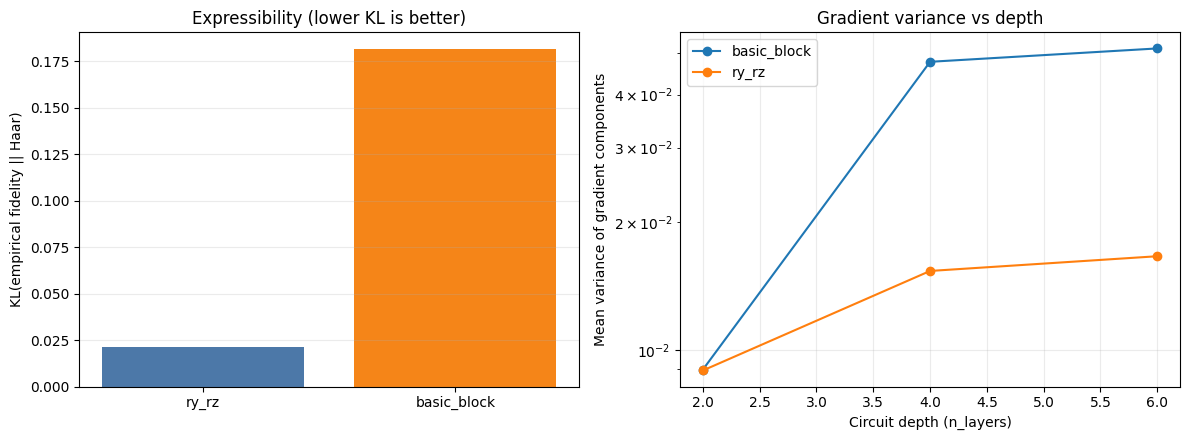

,ansatz,n_qubits,n_layers,n_trainable,kl_divergence_to_haar,mean_fidelity,std_fidelity,meyer_wallach_mean,meyer_wallach_std
0,ry_rz,3,4,9,0.0212,0.1278,0.1126,0.5878,0.2091
1,basic_block,3,4,9,0.1815,0.1221,0.1457,0.5154,0.2735


,ansatz,depth,n_trainable,gradient_variance_mean,gradient_variance_std,gradient_abs_mean,n_initializations,batch_size
0,basic_block,2,3,0.008991,0.008268,0.058285,12,6
1,basic_block,4,9,0.047778,0.024381,0.157296,12,6
2,basic_block,6,15,0.051372,0.022278,0.159481,12,6
3,ry_rz,2,3,0.008948,0.009724,0.052676,12,6
4,ry_rz,4,9,0.015356,0.010599,0.084607,12,6
5,ry_rz,6,15,0.016633,0.008234,0.086339,12,6


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

from qml_project import compare_ansatz_expressibility, gradient_variance_vs_depth

ansatze = ["basic_block", "ry_rz"]

expressibility_df = compare_ansatz_expressibility(
    ansatze=ansatze,
    n_qubits=3,
    n_features=3,
    n_classes=2,
    n_layers=4,
    n_samples=128,
    n_pairs=768,
    n_bins=50,
    seed=42,
)

depths = [2, 4, 6]
grad_var_df = pd.concat(
    [
        gradient_variance_vs_depth(
            ansatz=ansatz,
            n_qubits=3,
            n_features=3,
            n_classes=2,
            depths=depths,
            cz_strategy="linear",
            cz_seed=42,
            n_initializations=12,
            batch_size=6,
            finite_diff_eps=1e-3,
            seed=42,
        )
        for ansatz in ansatze
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(expressibility_df["ansatz"], expressibility_df["kl_divergence_to_haar"], color=["#4C78A8", "#F58518"])
axes[0].set_title("Expressibility (lower KL is better)")
axes[0].set_ylabel("KL(empirical fidelity || Haar)")
axes[0].grid(axis="y", alpha=0.25)

for ansatz in ansatze:
    sub = grad_var_df[grad_var_df["ansatz"] == ansatz]
    axes[1].plot(sub["depth"], sub["gradient_variance_mean"], marker="o", label=ansatz)
axes[1].set_title("Gradient variance vs depth")
axes[1].set_xlabel("Circuit depth (n_layers)")
axes[1].set_ylabel("Mean variance of gradient components")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

display(expressibility_df.round(4))
display(grad_var_df.round(6))

Interpretation checklist for model selection:

1. **Expressibility:** prefer lower KL only when trainability remains acceptable; very high expressibility alone can still be hard to optimise.
2. **Entangling capability:** $Q$ should be non-trivial but not interpreted in isolation; for Nim's bitwise XOR structure, moderate entanglement is often sufficient.
3. **Barren plateau risk ([13]):** if gradient variance collapses quickly with depth, keep the shallower depth for the main OOD sweep and avoid deeper ansatzes unless there is a clear balanced-accuracy gain.

These diagnostics are used as architecture filters before larger 10+ seed VQC sweeps.

## 6. Training and Optimisation

*Supports: QML Model Design & Optimisation (30%)*

COBYLA optimisation (SPSA fallback) with 10+ seeds per configuration. MLflow experiment tracking. Sample-efficiency sweep (train on each subset size: 50, 100, full). Symmetry controlled experiment (raw vs augmented vs canonical vs equivariant). Loss function exploration.

## 7. Experimental Design

*Supports: Experimental Design (20%)*

Noise sweep (depolarising rates 0.001–0.05 + backend-specific noise model from IBM calibration data). Error mitigation: measurement error mitigation (readout correction matrix) and zero-noise extrapolation (ZNE). Shot budget analysis (8192 down to 512 shots). Transfer learning experiment (train $M = 3$, fine-tune $M = 5$, test $M = 7$). Device pipeline design and budget.

## 8. Simulated QML Results

Sample-efficiency curves (accuracy and win rate vs training set size 50, 100, full=215 for all pipelines, mean $\pm$ std over 10+ seeds with 95% bootstrap CI). Generalisation and symmetry results from the same experiment (train M≤5, test M>5). Quantum kernel matrix visualisations.

### 8.1 Simulated VQC OOD sample-efficiency sweep

We now run the full OOD protocol for simulated VQC:

- Train on $M \leq 5$ subsets with sizes $50$, $100$, and full train ($215$ states).
- Evaluate on held-out OOD states with at least one heap $> 5$ (same split as the classical baseline).
- Use $10$ seeds (`0..9`) per training size.
- Log each run to MLflow (`simulated-vqc-ood`).
- Report OOD test accuracy, balanced accuracy, MCC, and win rate vs random-play policy.

In [ ]:
import numpy as np
import pandas as pd

from qml_project import build_circuit, run_simulated_vqc_ood_sweep
from qml_project.nim import prepare_experiment_data


def angle_features(states: np.ndarray, m_max: int = 7) -> np.ndarray:
    return (states.astype(np.float64) / float(m_max)) * np.pi


data = prepare_experiment_data(
    k=3,
    M=7,
    M_train=5,
    subset_sizes=(50, 100),
    random_state=42,
)

X_train = angle_features(data.split.X_train)
X_test = angle_features(data.split.X_test)
y_train = data.split.y_train
y_test = data.split.y_test


def vc_builder():
    return build_circuit(
        n_qubits=3,
        n_features=3,
        n_classes=2,
        n_layers=4,
        ansatz="ry_rz",
        cz_strategy="linear",
        cz_seed=42,
    )


sim_vqc_sweep = run_simulated_vqc_ood_sweep(
    vc_builder,
    X_train,
    y_train,
    X_test,
    y_test,
    train_sizes=(50, 100, "full"),
    seeds=tuple(range(10)),
    max_iter=120,
    test_shots=300,
    feature_fn_for_policy=angle_features,
    compute_win_rate=True,
    n_games_win_rate=200,
    game_k=3,
    game_M=7,
    decision_rule="argmax",
    observable="bitstring_probs",
    loss_name="softmax_nll",
    mlflow_experiment="simulated-vqc-ood",
    mlflow_run_prefix="ry_rz-softmax",
    verbose=False,
)

sim_vqc_df = (
    sim_vqc_sweep.to_dataframe()
    .sort_values(["train_size", "seed"])
    .reset_index(drop=True)
)
sim_vqc_df.head()

2026/04/03 17:02:59 INFO mlflow.tracking.fluent: Experiment with name 'simulated-vqc-ood' does not exist. Creating a new experiment.


In [ ]:
import matplotlib.pyplot as plt

summary_df = sim_vqc_sweep.summary(group_cols=("train_size", "ansatz", "loss_name"))
stats_df = sim_vqc_sweep.statistical_tests(
    metrics=("test_accuracy", "win_rate"),
    train_sizes=(50, 100, 215),
    alpha=0.05,
)
power_law_df = sim_vqc_sweep.power_law_fits(
    metrics=("test_accuracy", "win_rate"),
    train_sizes=(50, 100, 215),
)

summary_plot = summary_df.sort_values("train_size")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in [
    (axes[0], "test_accuracy", "OOD test accuracy vs training size"),
    (axes[1], "win_rate", "Win rate vs random vs training size"),
]:
    x = summary_plot["train_size"].to_numpy()
    y = summary_plot[f"{metric}_mean"].to_numpy()
    lo = summary_plot[f"{metric}_ci_low"].to_numpy()
    hi = summary_plot[f"{metric}_ci_high"].to_numpy()
    ax.plot(x, y, marker="o", label="simulated VQC")
    ax.fill_between(x, lo, hi, alpha=0.2, label="95% bootstrap CI")
    ax.set_title(title)
    ax.set_xlabel("Training size")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

display(
    summary_df[
        [
            "train_size",
            "test_accuracy_mean",
            "test_accuracy_std",
            "win_rate_mean",
            "win_rate_std",
            "balanced_accuracy_mean",
            "mcc_mean",
            "n_runs",
        ]
    ].sort_values("train_size")
)
display(stats_df.sort_values(["metric", "size_a", "size_b"]))
display(power_law_df)

Figure: Simulated VQC sample-efficiency in the OOD regime (`M \leq 5` train, `M > 5` test) with mean and 95% bootstrap confidence intervals over 10 seeds. The statistical table reports paired Wilcoxon tests with Bonferroni correction and paired effect sizes, and the power-law table reports fitted parameters for $\mathrm{metric}(n) = a - b n^{-c}$.

## 9. Quantum Device Inference

*Supports: Experimental Design (20%); Evaluation & Discussion (15%)*

IBM Quantum free tier, inference-only (no training on device). Budget-conscious test set (30–50 stratified states, 1024 shots). Measurement error mitigation (readout correction matrix) applied to device results. Three-way comparison: raw device vs readout-corrected device vs simulated noisy results.

## 10. Four-Way Comparison

*Supports: Evaluation Methodology and Discussion of Findings (15%)*

Compare all pipelines (classical, quantum kernel SVM, simulated VQC, device VQC) on: balanced accuracy, MCC, win rate, sample efficiency (accuracy and win rate vs training set size 50, 100, full=215), cost (wall-clock time, shots, credits), speed (per-sample latency), interpretability. Formal statistical tests: paired Wilcoxon signed-rank with Bonferroni correction, Cohen's d effect sizes, power-law learning curve fits ($\text{accuracy} \sim a - b \cdot n^{-c}$), 95% bootstrap confidence intervals.

## 11. Discussion

### 11.1 Related Work

QML sample efficiency (Huang et al. 2021), QML for combinatorial games, quantum kernel theory (Schuld & Killoran [18]), noise resilience and shallow circuits ([5], [7], [20]), QML vs classical benchmarks ([8], [10]).

### 11.2 Limitations

Small state space (511 states), deterministic game, limited qubits (3–9), optimiser convergence, shot noise, class imbalance at small sample sizes, no real quantum advantage claim.

### 11.3 Adversarial and Hard-Case Analysis

Confusion geography heatmaps, failure clustering by Nim-sum magnitude, disagreement analysis between pipelines.

## 12. References

- [5] Cincio, L. et al. — Variational hybrid algorithms.
- [7] Fontana, E. et al. — Noise resilience.
- [8] Houssein, E. A. et al. — QML state-of-the-art survey.
- [10] Khan, T. M. & Robles-Kelly, A. — Quantum vs classical ML.
- [13] McClean, J. R. et al. — Barren plateaus in QNNs.
- [18] Schuld, M. & Killoran, N. — Quantum feature spaces.
- [20] Selig, P. et al. — Noisy shallow circuits, angle mapping.
- Huang, H.-Y. et al. (2021) — Power of data in quantum machine learning.
- Sim, S. et al. (2019) — Expressibility and entangling capability of parameterized quantum circuits.